# **WHEEL DIAMETER**

In [1]:
import pandas as pd
df = pd.read_csv("wheel2.csv")
df

,Date,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
0,2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.000000
1,2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.000000
2,2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.000000
3,2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.000000
4,2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4918,2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
4919,2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
4920,2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727
4921,2025-03-13,T58,M2,BOG#2,X4-LHS,812.10,30.01,0,2025Q1,11,90,147.272727


In [2]:
import numpy as np
import matplotlib.pyplot as plt

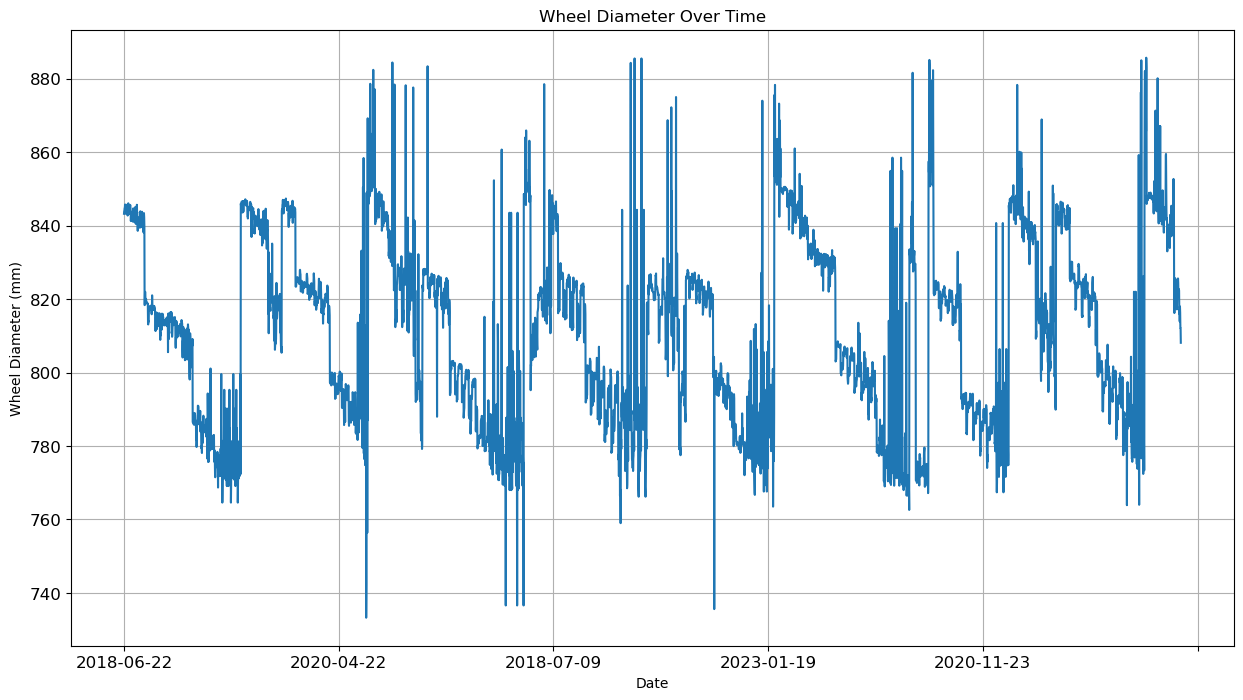

In [3]:
#plot the time series data
df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['WheelDiameter'].plot(figsize=(15, 8), title='Wheel Diameter Over Time', fontsize=12)
plt.ylabel('Wheel Diameter (mm)')
plt.grid(True)

In [4]:
training_wd = df[0:4429] # in-sample data (training data)
testing_wd = df[4429:] #out-sample data (testing data)

In [5]:
training_wd

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [6]:
testing_wd

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-11-12,T58,M2,BOG#1,X1-LHS,824.86,32.30,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X1-RHS,824.94,32.18,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-LHS,817.10,31.94,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-RHS,817.09,32.24,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#2,X3-LHS,817.47,32.18,0,2018Q4,2,92,828.000000
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model1 = ExponentialSmoothing(training_wd['WheelDiameter'], trend='add', seasonal='add', seasonal_periods=4).fit()
model1.summary()

C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Dep. Variable:,WheelDiameter,No. Observations:,4429
Model:,ExponentialSmoothing,SSE,474023.974
Optimized:,True,AIC,20713.089
Trend:,Additive,BIC,20764.257
Seasonal:,Additive,AICC,20713.139
Seasonal Periods:,4,Date:,"Thu, 12 Jun 2025"
Box-Cox:,False,Time:,08:38:28
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3959666,alpha,True
smoothing_trend,0.0002235,beta,True


In [8]:
# initialize variables for storing predictions and actual values
predictions1 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wd)):
    # make one-step ahead forecast
    yhat = model1.forecast()

    # store prediction and actual value
    predictions1.append(yhat)
    actuals.append(testing_wd.iloc[i])

    # add actual value to training data
    training_wd = pd.concat([training_wd, pd.DataFrame([testing_wd.iloc[i]], columns=training_wd.columns)], ignore_index=True)

    # retrain model on updated training data
    model1 = ExponentialSmoothing(training_wd['WheelDiameter'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model1.summary()

    actual_value1 = testing_wd.iloc[-1]

C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
predictions1

[4429    824.856834
 dtype: float64,
 4430    825.13771
 dtype: float64,
 4431    824.972694
 dtype: float64,
 4432    821.929236
 dtype: float64,
 4433    819.665859
 dtype: float64,
 4434    819.155415
 dtype: float64,
 4435    818.322981
 dtype: float64,
 4436    820.722646
 dtype: float64,
 4437    821.857553
 dtype: float64,
 4438    822.775311
 dtype: float64,
 4439    822.91203
 dtype: float64,
 4440    823.031848
 dtype: float64,
 4441    822.726586
 dtype: float64,
 4442    823.719852
 dtype: float64,
 4443    823.550078
 dtype: float64,
 4444    823.58883
 dtype: float64,
 4445    823.225813
 dtype: float64,
 4446    825.88605
 dtype: float64,
 4447    827.17893
 dtype: float64,
 4448    827.901172
 dtype: float64,
 4449    828.075783
 dtype: float64,
 4450    826.972759
 dtype: float64,
 4451    825.906671
 dtype: float64,
 4452    825.463795
 dtype: float64,
 4453    824.681603
 dtype: float64,
 4454    824.742571
 dtype: float64,
 4455    824.398016
 dtype: float64,
 4456 

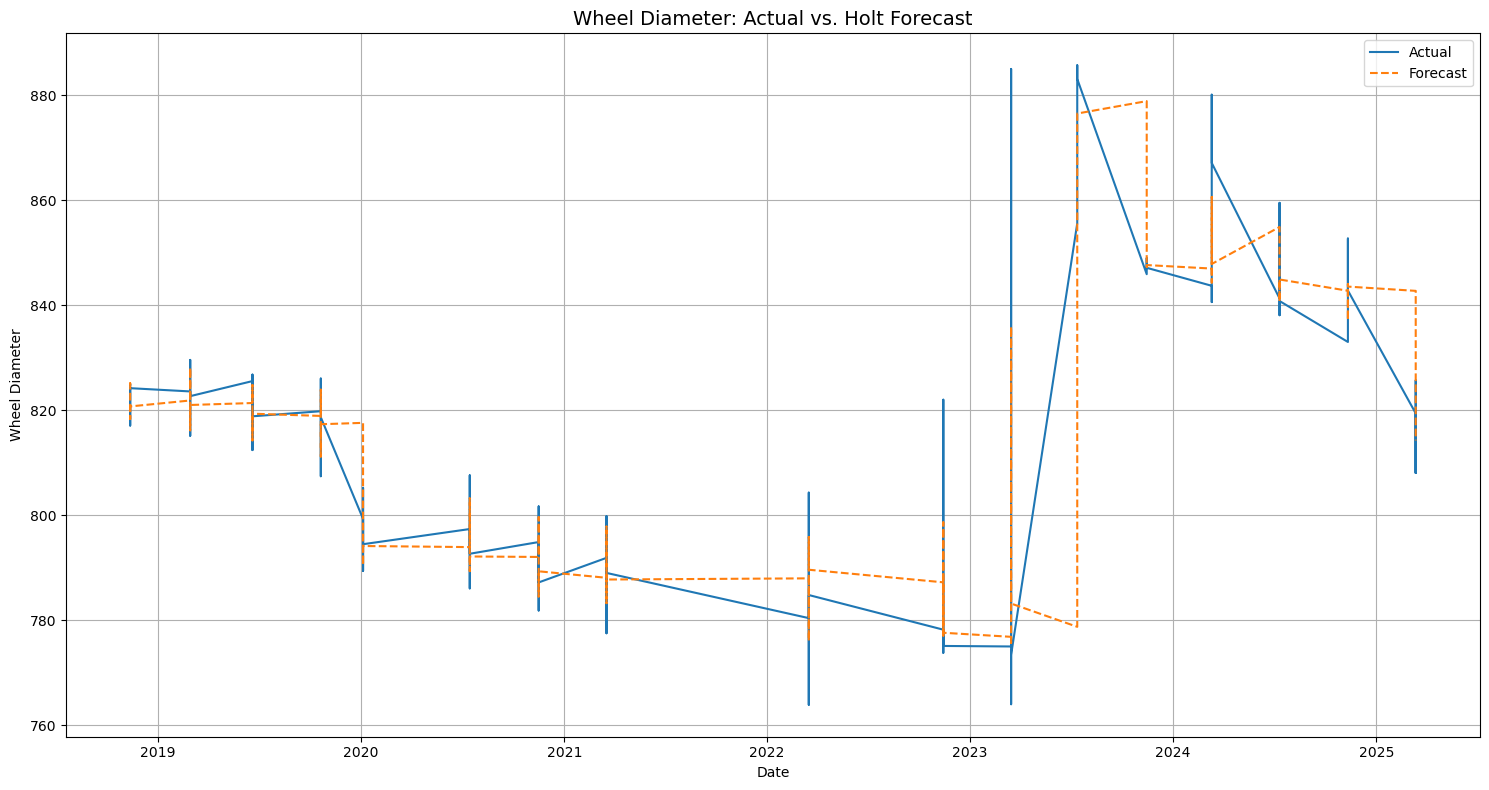

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_wd.index.dtype, np.datetime64):
    testing_wd.index = pd.to_datetime(testing_wd.index)

# Convert predictions into array and ensure shape matches testing set
a = np.array(predictions1)

# Create DataFrame for forecast with the same index as testing
testing_forecasted1 = pd.DataFrame(a, columns=['forecast1'], index=testing_wd.index)

# Combine actual and predicted values
result = pd.DataFrame({
    'Actual WheelDiameter': testing_wd['WheelDiameter'],
    'Predicted WheelDiameter': testing_forecasted1['forecast1']
})

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(result['Actual WheelDiameter'], label='Actual')
plt.plot(result['Predicted WheelDiameter'], label='Forecast', linestyle='--')
plt.title('Wheel Diameter: Actual vs. Holt Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wheel Diameter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Display the top rows of the result DataFrame
print(result.head(10))

            Actual WheelDiameter  Predicted WheelDiameter
Date                                                     
2018-11-12                824.86               824.856834
2018-11-12                824.94               825.137710
2018-11-12                817.10               824.972694
2018-11-12                817.09               821.929236
2018-11-12                817.47               819.665859
2018-11-12                817.51               819.155415
2018-11-12                824.14               818.322981
2018-11-12                824.20               820.722646
2019-02-28                823.58               821.857553
2019-02-28                823.36               822.775311


In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true = testing_wd['WheelDiameter'].values
y_pred = testing_forecasted1['forecast1'].values

# Evaluation metrics
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")


R² Score      : 0.7820
MSE           : 142.1211
RMSE          : 11.9215
MAE           : 5.6349
MAPE (%)      : 0.69%


In [13]:
import pandas as pd

# Parameters
future_start_date = '2025-10-01'
n_periods = 5
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values1 = model1.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts1 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values1
    })
    forecasts1 = pd.concat([forecasts1, temp_df], ignore_index=True)

# Display result
print(forecasts1)


   TrainID       Date    Forecast
0      T01 2025-12-31  811.348975
1      T01 2026-03-31  811.653313
2      T01 2026-06-30  811.233759
3      T01 2026-09-30  811.798696
4      T01 2026-12-31  811.329072
5      T05 2025-12-31  811.348975
6      T05 2026-03-31  811.653313
7      T05 2026-06-30  811.233759
8      T05 2026-09-30  811.798696
9      T05 2026-12-31  811.329072
10     T25 2025-12-31  811.348975
11     T25 2026-03-31  811.653313
12     T25 2026-06-30  811.233759
13     T25 2026-09-30  811.798696
14     T25 2026-12-31  811.329072
15     T45 2025-12-31  811.348975
16     T45 2026-03-31  811.653313
17     T45 2026-06-30  811.233759
18     T45 2026-09-30  811.798696
19     T45 2026-12-31  811.329072
20     T46 2025-12-31  811.348975
21     T46 2026-03-31  811.653313
22     T46 2026-06-30  811.233759
23     T46 2026-09-30  811.798696
24     T46 2026-12-31  811.329072
25     T55 2025-12-31  811.348975
26     T55 2026-03-31  811.653313
27     T55 2026-06-30  811.233759
28     T55 202

C:\Users\SuzLiz\AppData\Local\Temp\ipykernel_8344\183152527.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


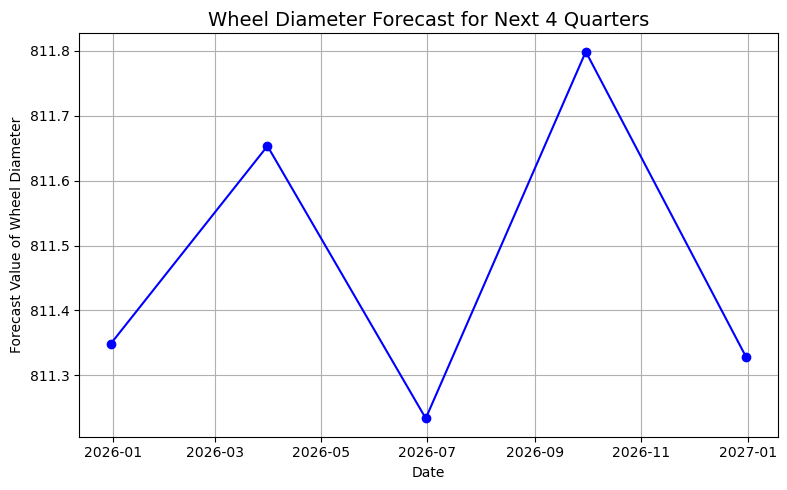

In [14]:
import matplotlib.pyplot as plt

# Plot the overall forecast (only once since all TrainIDs share the same forecast)
plt.figure(figsize=(8, 5))
plt.plot(future_dates, forecast_values1, marker='o', linestyle='-', color='blue')

# Add labels and title
plt.title('Wheel Diameter Forecast for Next 4 Quarters', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Forecast Value of Wheel Diameter')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# **MTBF**

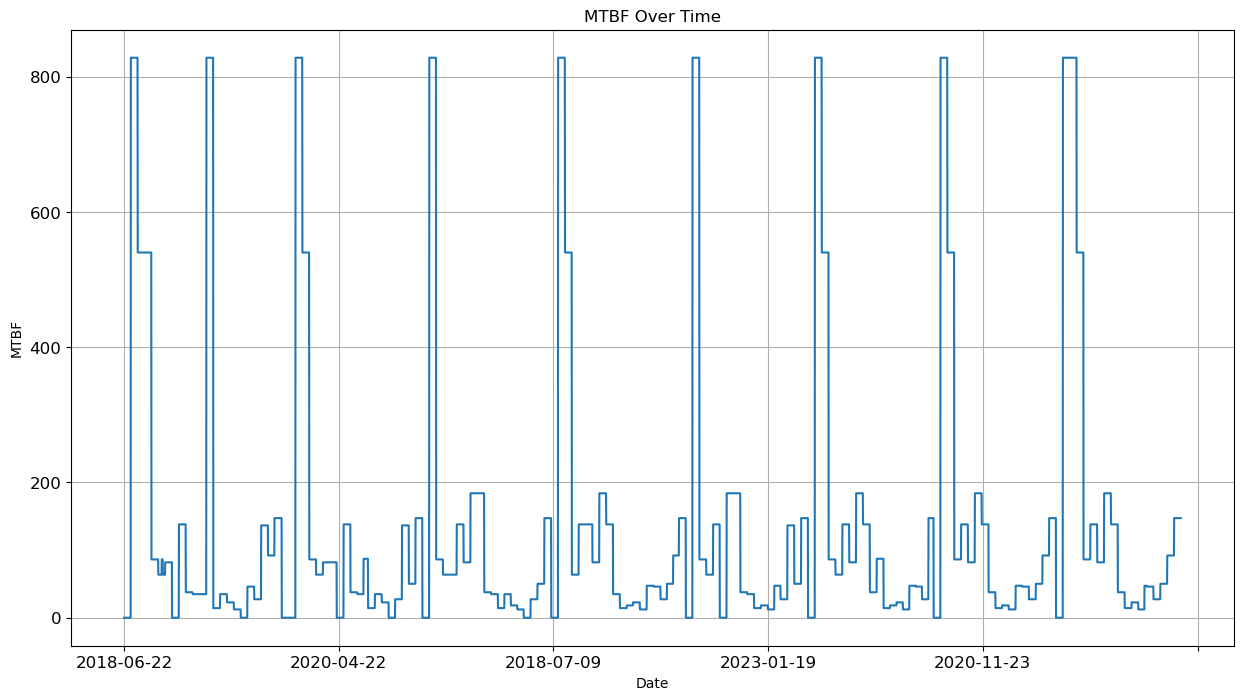

In [15]:
#plot the time series data
#df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['MTBF'].plot(figsize=(15, 8), title='MTBF Over Time', fontsize=12)
plt.ylabel('MTBF')
plt.grid(True)

In [16]:
training_mtbf = df[0:4429] # in-sample data (training data)
testing_mtbf = df[4429:] #out-sample data (testing data)

In [17]:
training_mtbf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [18]:
testing_mtbf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-11-12,T58,M2,BOG#1,X1-LHS,824.86,32.30,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X1-RHS,824.94,32.18,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-LHS,817.10,31.94,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-RHS,817.09,32.24,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#2,X3-LHS,817.47,32.18,0,2018Q4,2,92,828.000000
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model2 = ExponentialSmoothing(training_wd['MTBF'], trend='add', seasonal='add', seasonal_periods=4).fit()
model2.summary()

Dep. Variable:,MTBF,No. Observations:,4923
Model:,ExponentialSmoothing,SSE,10249337.468
Optimized:,True,AIC,37632.890
Trend:,Additive,BIC,37684.904
Seasonal:,Additive,AICC,37632.935
Seasonal Periods:,4,Date:,"Thu, 12 Jun 2025"
Box-Cox:,False,Time:,08:47:45
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9950041,alpha,True
smoothing_trend,9.9918e-05,beta,True


In [20]:
# initialize variables for storing predictions and actual values
predictions2 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wd)):
    # make one-step ahead forecast
    yhat = model2.forecast()

    # store prediction and actual value
    predictions2.append(yhat)
    actuals.append(testing_mtbf.iloc[i])

    # add actual value to training data
    training_mtbf = pd.concat([training_mtbf, pd.DataFrame([testing_mtbf.iloc[i]], columns=training_mtbf.columns)], ignore_index=True)

    # retrain model on updated training data
    model2 = ExponentialSmoothing(training_mtbf['MTBF'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model2.summary()

    actual_value2 = testing_mtbf.iloc[-1]

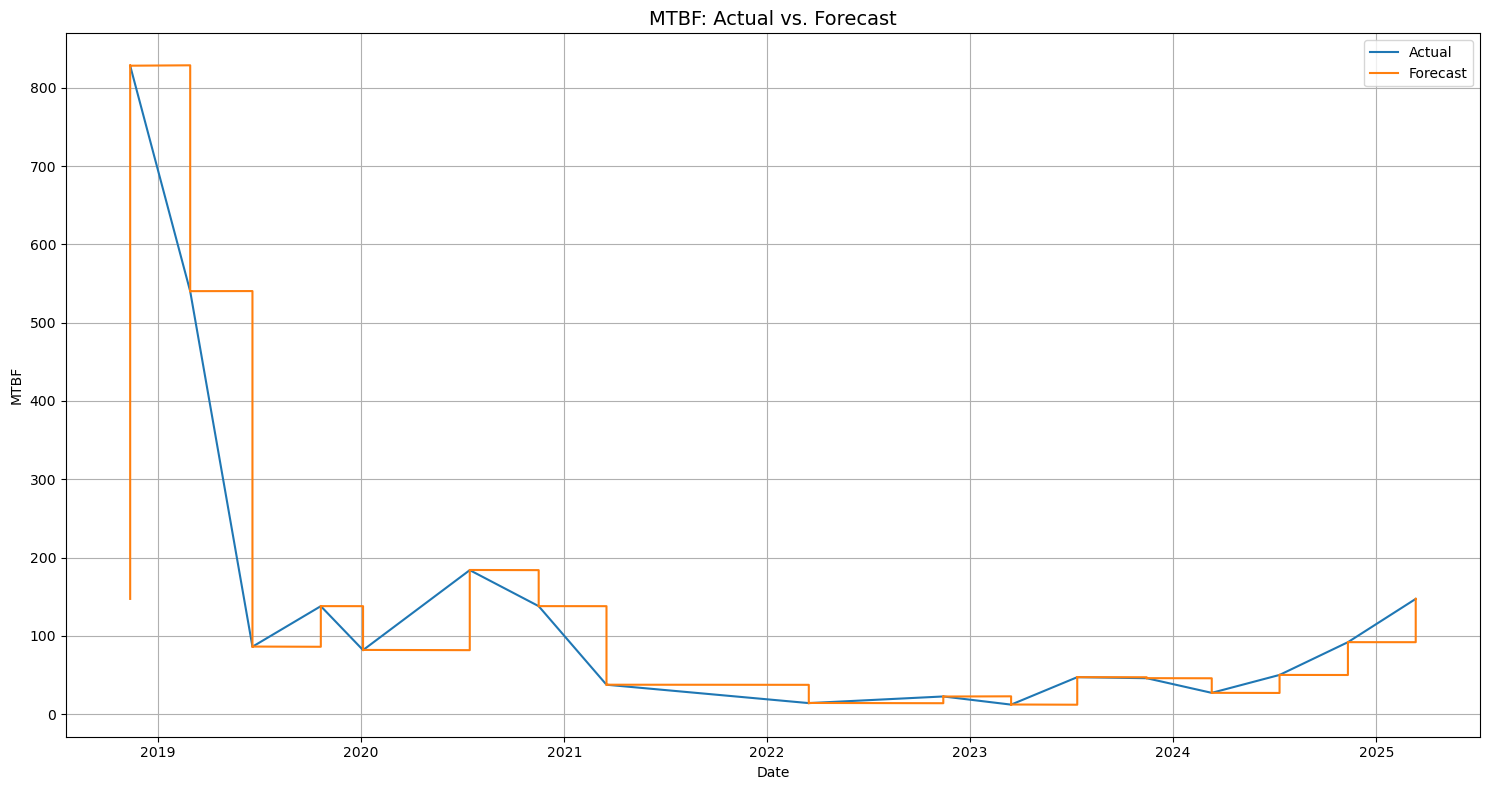

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_mtbf.index.dtype, np.datetime64):
    testing_mtbf.index = pd.to_datetime(testing_mtbf.index)

# Convert predictions into array and ensure shape matches testing set
b = np.array(predictions2)

# Create DataFrame for forecast with the same index as testing
testing_forecasted2 = pd.DataFrame(b, columns=['forecast2'], index=testing_mtbf.index)

# Combine actual and predicted values
result2 = pd.DataFrame({
    'Actual MTBF': testing_mtbf['MTBF'],
    'Predicted MTBF': testing_forecasted2['forecast2']
})

# Plotting
plt.figure(figsize=(15, 8))
# Use result2 which contains the MTBF actual and predicted values
plt.plot(result2['Actual MTBF'], label='Actual')
plt.plot(result2['Predicted MTBF'], label='Forecast')
plt.title('MTBF: Actual vs. Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('MTBF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Display the top rows of the result DataFrame
print(result2.head(10))

            Actual MTBF  Predicted MTBF
Date                                   
2018-11-12        828.0      147.262886
2018-11-12        828.0      828.015983
2018-11-12        828.0      827.922966
2018-11-12        828.0      828.107999
2018-11-12        828.0      828.609717
2018-11-12        828.0      828.010867
2018-11-12        828.0      827.919070
2018-11-12        828.0      828.107964
2019-02-28        540.0      828.608268
2019-02-28        540.0      541.463634


In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true2 = testing_mtbf['MTBF'].values
y_pred2 = testing_forecasted2['forecast2'].values

# Evaluation metrics
r2 = r2_score(y_true2, y_pred2)
mse = mean_squared_error(y_true2, y_pred2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true2, y_pred2)
mape = np.mean(np.abs((y_true2 - y_pred2) / y_true2)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")

R² Score      : 0.9331
MSE           : 1597.2671
RMSE          : 39.9658
MAE           : 4.1458
MAPE (%)      : 3.65%


In [24]:
import pandas as pd

# Parameters
future_start_date = '2025-10-01'
n_periods = 5
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values2 = model2.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts2 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values2
    })
    forecasts2 = pd.concat([forecasts2, temp_df], ignore_index=True)

# Display result
print(forecasts2)

   TrainID       Date    Forecast
0      T01 2025-12-31  147.262886
1      T01 2026-03-31  147.442981
2      T01 2026-06-30  147.344513
3      T01 2026-09-30  147.387407
4      T01 2026-12-31  147.377354
5      T05 2025-12-31  147.262886
6      T05 2026-03-31  147.442981
7      T05 2026-06-30  147.344513
8      T05 2026-09-30  147.387407
9      T05 2026-12-31  147.377354
10     T25 2025-12-31  147.262886
11     T25 2026-03-31  147.442981
12     T25 2026-06-30  147.344513
13     T25 2026-09-30  147.387407
14     T25 2026-12-31  147.377354
15     T45 2025-12-31  147.262886
16     T45 2026-03-31  147.442981
17     T45 2026-06-30  147.344513
18     T45 2026-09-30  147.387407
19     T45 2026-12-31  147.377354
20     T46 2025-12-31  147.262886
21     T46 2026-03-31  147.442981
22     T46 2026-06-30  147.344513
23     T46 2026-09-30  147.387407
24     T46 2026-12-31  147.377354
25     T55 2025-12-31  147.262886
26     T55 2026-03-31  147.442981
27     T55 2026-06-30  147.344513
28     T55 202

C:\Users\SuzLiz\AppData\Local\Temp\ipykernel_8344\961788062.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


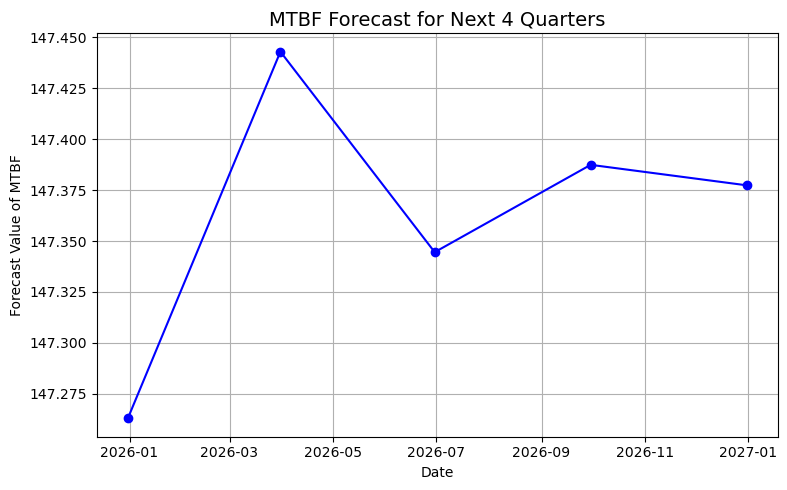

In [25]:
import matplotlib.pyplot as plt

# Plot the overall forecast (only once since all TrainIDs share the same forecast)
plt.figure(figsize=(8, 5))
plt.plot(future_dates, forecast_values2, marker='o', linestyle='-', color='blue')

# Add labels and title
plt.title('MTBF Forecast for Next 4 Quarters', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Forecast Value of MTBF')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# **WHEEL FLANGE**

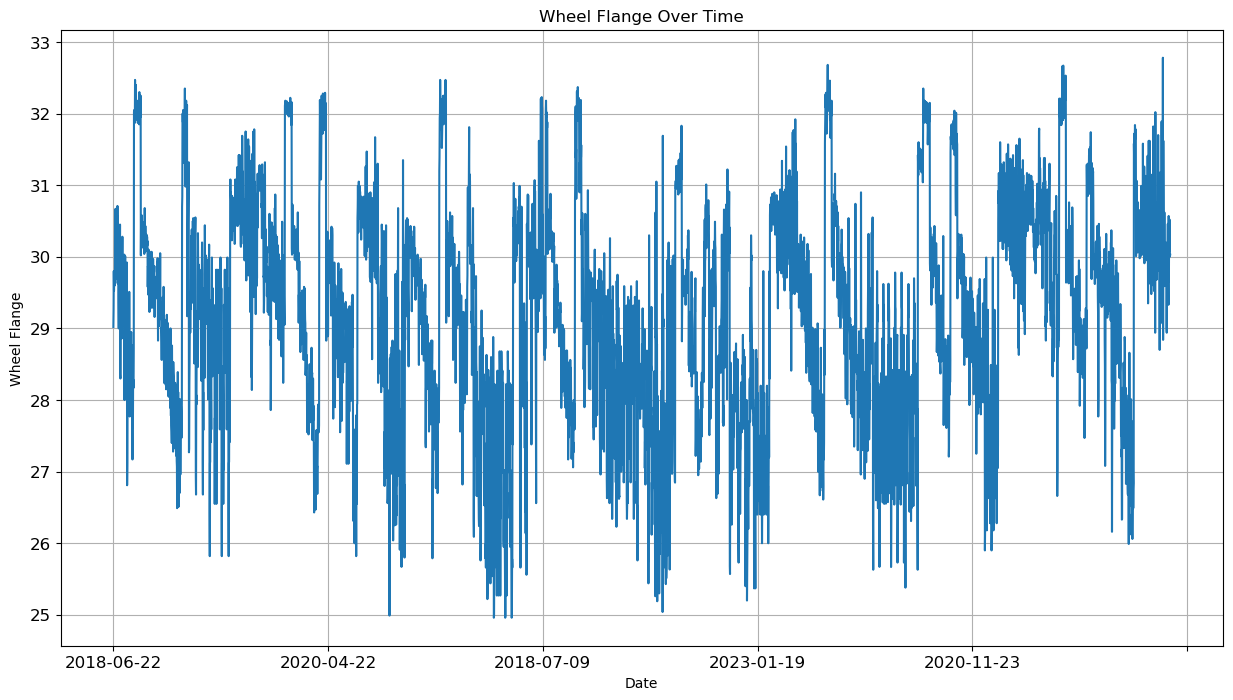

In [26]:
df['WheelFlange'].plot(figsize=(15, 8), title='Wheel Flange Over Time', fontsize=12)
plt.ylabel('Wheel Flange')
plt.grid(True)

In [27]:
training_wf = df[0:4429] # in-sample data (training data)
testing_wf = df[4429:] #out-sample data (testing data)

In [28]:
training_wf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [29]:
training_wf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model3 = ExponentialSmoothing(training_wf['WheelFlange'], trend='add', seasonal='add', seasonal_periods=4).fit()
model3.summary()

C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Dep. Variable:,WheelFlange,No. Observations:,4429
Model:,ExponentialSmoothing,SSE,2703.732
Optimized:,True,AIC,-2169.892
Trend:,Additive,BIC,-2118.724
Seasonal:,Additive,AICC,-2169.842
Seasonal Periods:,4,Date:,"Thu, 12 Jun 2025"
Box-Cox:,False,Time:,08:56:31
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5587588,alpha,True
smoothing_trend,6.1235e-19,beta,True


In [31]:
# initialize variables for storing predictions and actual values
predictions3 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wf)):
    # make one-step ahead forecast
    yhat = model3.forecast()

    # store prediction and actual value
    predictions3.append(yhat)
    actuals.append(testing_wf.iloc[i])

    # add actual value to training data
    training_wf = pd.concat([training_wf, pd.DataFrame([testing_wf.iloc[i]], columns=training_wf.columns)], ignore_index=True)

    # retrain model on updated training data
    model3 = ExponentialSmoothing(training_wf['WheelFlange'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model3.summary()

    actual_value3= testing_wf.iloc[-1]

C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\SuzLiz\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


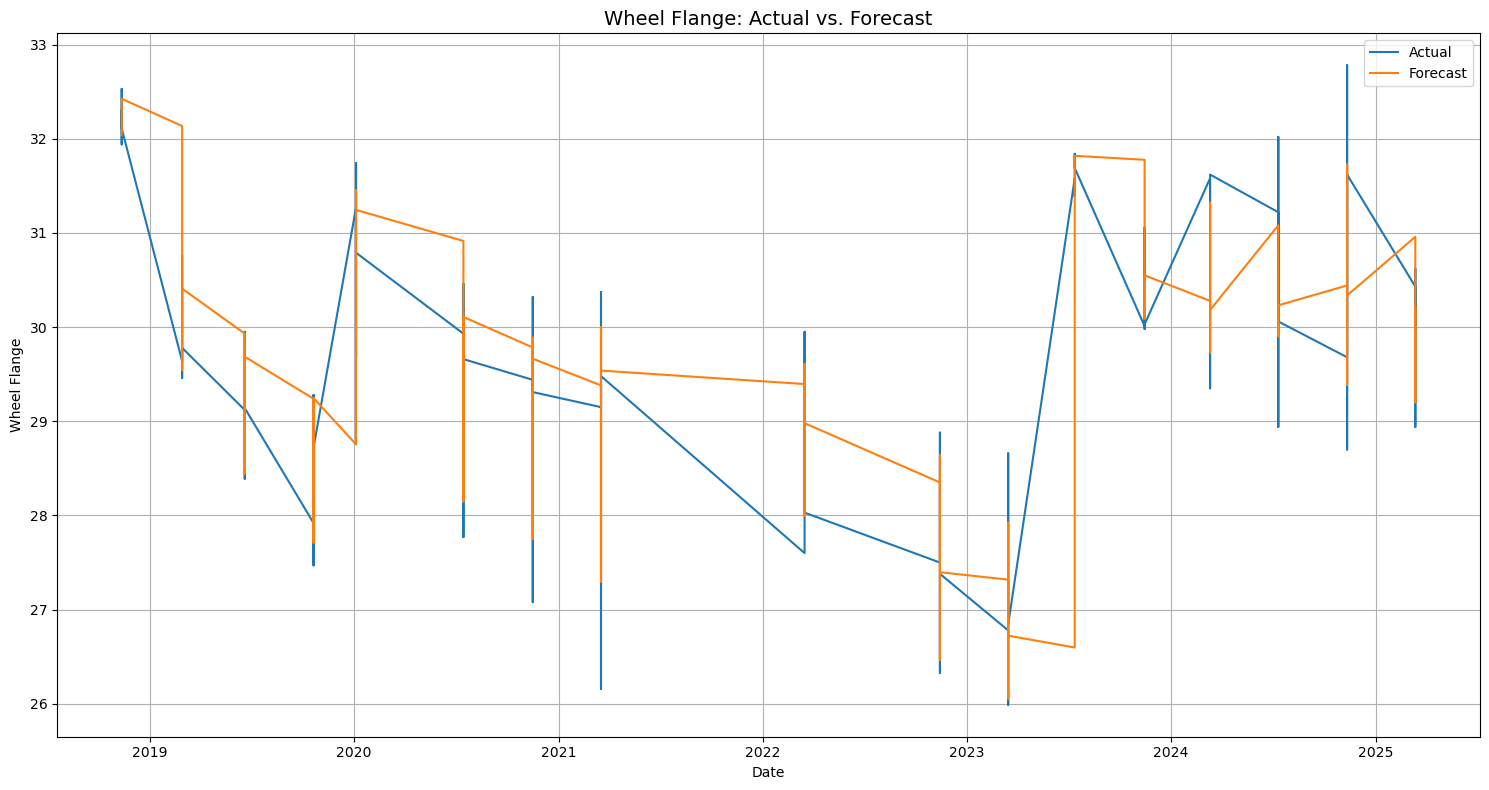

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_wf.index.dtype, np.datetime64):
    testing_wf.index = pd.to_datetime(testing_wf.index)

# Convert predictions into array and ensure shape matches testing set
c = np.array(predictions3)

# Create DataFrame for forecast with the same index as testing
testing_forecasted3 = pd.DataFrame(c, columns=['forecast3'], index=testing_wf.index)

# Combine actual and predicted values
result3 = pd.DataFrame({
    'Actual Wheel Flange': testing_wf['WheelFlange'],
    'Predicted Wheel Flange': testing_forecasted3['forecast3']
})

# Plotting
plt.figure(figsize=(15, 8))
# Use result2 which contains the MTBF actual and predicted values
plt.plot(result3['Actual Wheel Flange'], label='Actual')
plt.plot(result3['Predicted Wheel Flange'], label='Forecast')
plt.title('Wheel Flange: Actual vs. Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wheel Flange')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Display the top rows of the result DataFrame
print(result3.head(10))

            Actual Wheel Flange  Predicted Wheel Flange
Date                                                   
2018-11-12                32.30               32.041446
2018-11-12                32.18               32.353789
2018-11-12                31.94               32.161813
2018-11-12                32.24               32.088038
2018-11-12                32.18               32.060574
2018-11-12                32.22               32.281685
2018-11-12                32.53               32.150447
2018-11-12                32.11               32.424491
2019-02-28                29.64               32.135529
2019-02-28                30.04               30.888972


In [34]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true3 = testing_wf['WheelFlange'].values
y_pred3 = testing_forecasted3['forecast3'].values

# Evaluation metrics
r2 = r2_score(y_true3, y_pred3)
mse = mean_squared_error(y_true3, y_pred3)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true3, y_pred3)
mape = np.mean(np.abs((y_true3 - y_pred3) / y_true3)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")

R² Score      : 0.6808
MSE           : 0.5148
RMSE          : 0.7175
MAE           : 0.5013
MAPE (%)      : 1.70%


In [35]:
import pandas as pd

# Parameters
future_start_date = '2025-10-01'
n_periods = 5
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values3 = model3.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts3 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values3
    })
    forecasts3 = pd.concat([forecasts3, temp_df], ignore_index=True)

# Display result
print(forecasts3)

C:\Users\SuzLiz\AppData\Local\Temp\ipykernel_8344\1111072543.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


   TrainID       Date   Forecast
0      T01 2025-12-31  30.148552
1      T01 2026-03-31  29.993013
2      T01 2026-06-30  29.917007
3      T01 2026-09-30  30.114324
4      T01 2026-12-31  30.149140
5      T05 2025-12-31  30.148552
6      T05 2026-03-31  29.993013
7      T05 2026-06-30  29.917007
8      T05 2026-09-30  30.114324
9      T05 2026-12-31  30.149140
10     T25 2025-12-31  30.148552
11     T25 2026-03-31  29.993013
12     T25 2026-06-30  29.917007
13     T25 2026-09-30  30.114324
14     T25 2026-12-31  30.149140
15     T45 2025-12-31  30.148552
16     T45 2026-03-31  29.993013
17     T45 2026-06-30  29.917007
18     T45 2026-09-30  30.114324
19     T45 2026-12-31  30.149140
20     T46 2025-12-31  30.148552
21     T46 2026-03-31  29.993013
22     T46 2026-06-30  29.917007
23     T46 2026-09-30  30.114324
24     T46 2026-12-31  30.149140
25     T55 2025-12-31  30.148552
26     T55 2026-03-31  29.993013
27     T55 2026-06-30  29.917007
28     T55 2026-09-30  30.114324
29     T55

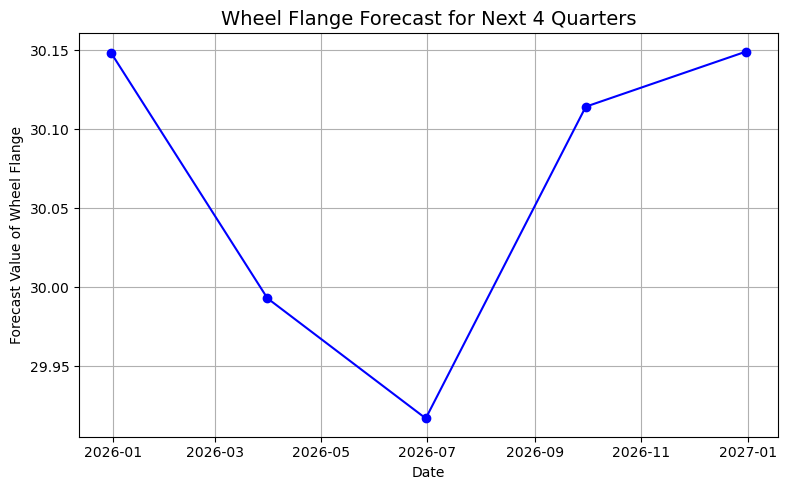

In [36]:
import matplotlib.pyplot as plt

# Plot the overall forecast (only once since all TrainIDs share the same forecast)
plt.figure(figsize=(8, 5))
plt.plot(future_dates, forecast_values3, marker='o', linestyle='-', color='blue')

# Add labels and title
plt.title('Wheel Flange Forecast for Next 4 Quarters', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Forecast Value of Wheel Flange')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [37]:
df = df.reset_index()

In [38]:
import joblib
joblib.dump(model1, "model1_wheel_diameter.pkl")
joblib.dump(model2, "model2_mtbf.pkl")
joblib.dump(model3, "model3_wheel_flange.pkl")

['model3_wheel_flange.pkl']

GUI

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
try:
    import joblib
    JOBLIB_AVAILABLE = True
except ImportError:
    JOBLIB_AVAILABLE = False
    print("Warning: joblib not available. Using mock predictions.")

class WheelMaintenancePredictionGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Wheel Maintenance Prediction System")
        self.root.geometry("1000x800")
        self.root.configure(bg='#f0f0f0')
        
        # Define color scheme
        self.colors = {
            'bg_primary': '#2c3e50',      # Dark blue-gray
            'bg_secondary': '#34495e',    # Lighter blue-gray
            'bg_light': '#ecf0f1',        # Light gray
            'accent': '#3498db',          # Blue
            'success': '#27ae60',         # Green
            'warning': '#f39c12',         # Orange
            'danger': '#e74c3c',          # Red
            'text_light': '#ffffff',      # White
            'text_dark': '#2c3e50'        # Dark gray
        }
        
        # Configure ttk styles
        self.configure_styles()
        
        # Initialize models
        self.load_models()
        
        # Create main container
        self.create_main_interface()
        
        # Display initial message
        self.display_welcome_message()
    
    def configure_styles(self):
        """Configure custom styles for ttk widgets"""
        style = ttk.Style()
        
        # Configure frame styles
        style.configure('Title.TFrame', background=self.colors['bg_primary'])
        style.configure('Input.TFrame', background=self.colors['bg_light'], relief='raised', borderwidth=2)
        style.configure('Output.TFrame', background=self.colors['bg_light'], relief='sunken', borderwidth=2)
        
        # Configure label styles
        style.configure('Title.TLabel', background=self.colors['bg_primary'], 
                       foreground=self.colors['text_light'], font=('Arial', 18, 'bold'))
        style.configure('Heading.TLabel', font=('Arial', 12, 'bold'), 
                       foreground=self.colors['text_dark'])
        style.configure('Info.TLabel', font=('Arial', 9, 'italic'), 
                       foreground='#7f8c8d')
        
        # Configure button styles
        style.configure('Primary.TButton', font=('Arial', 11, 'bold'))
        style.configure('Success.TButton', font=('Arial', 10))
        style.configure('Warning.TButton', font=('Arial', 10))
    
    def create_main_interface(self):
        """Create the main interface layout"""
        # Title section
        title_frame = ttk.Frame(self.root, style='Title.TFrame', padding="20")
        title_frame.pack(fill='x')
        
        title_label = ttk.Label(title_frame, text="🔧 Wheel Maintenance Prediction System", 
                               style='Title.TLabel')
        title_label.pack()
        
        # Main content area
        content_frame = ttk.Frame(self.root, padding="20")
        content_frame.pack(fill='both', expand=True)
        
        # Left panel for inputs
        left_panel = ttk.Frame(content_frame, style='Input.TFrame', padding="15")
        left_panel.pack(side='left', fill='y', padx=(0, 10))
        
        # Right panel for outputs
        right_panel = ttk.Frame(content_frame, style='Output.TFrame', padding="15")
        right_panel.pack(side='right', fill='both', expand=True)
        
        # Create input section
        self.create_input_section(left_panel)
        
        # Create output section
        self.create_output_section(right_panel)
    
    def create_input_section(self, parent):
        """Create the input parameters section"""
        # Section title
        ttk.Label(parent, text="Input Parameters", style='Heading.TLabel').pack(pady=(0, 15))
        
        # Input fields frame
        inputs_frame = ttk.Frame(parent)
        inputs_frame.pack(fill='x')
        
        # Train ID
        self.create_input_field(inputs_frame, "Train ID:", 'train_id_var', 
                               ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58'], 
                               'T01', "Available train data", 0)
        
        # Car
        self.create_input_field(inputs_frame, "Car:", 'car_var', 
                               ['M1', 'T1', 'T2', 'M2'], 
                               'M1', "Motor/Trailer car", 1)
        
        # Bogie
        self.create_input_field(inputs_frame, "Bogie:", 'bogie_var', 
                               ['BOG#1', 'BOG#2'], 
                               'BOG#1', "Bogie selection", 2)
        
        # Axle
        self.create_input_field(inputs_frame, "Axle:", 'axle_var', 
                               ['X1-LHS', 'X1-RHS', 'X2-LHS', 'X2-RHS', 'X3-LHS', 'X3-RHS', 'X4-LHS', 'X4-RHS'], 
                               'X1-LHS', "Axle position", 3)
        
        # Date
        self.create_text_input(inputs_frame, "Date:", 'date_var', 
                              datetime.now().strftime("%Y-%m-%d"), "YYYY-MM-DD", 4)
        
        # Wheel Diameter
        self.create_text_input(inputs_frame, "Wheel Diameter (mm):", 'diameter_var', 
                              "", "Replacement if < 775mm", 5)
        
        # Wheel Flange
        self.create_text_input(inputs_frame, "Wheel Flange (mm):", 'flange_var', 
                              "", "Profiling if < 27.5mm", 6)
        
        # Failures per Quarter
        self.create_text_input(inputs_frame, "Failures per Quarter:", 'failures_var', 
                              "1", "For MTBF calculation", 7)
        
        # Predict button
        predict_btn = ttk.Button(inputs_frame, text="🔍 Predict Maintenance", 
                                style='Primary.TButton', command=self.predict_maintenance)
        predict_btn.grid(row=8, column=0, columnspan=3, pady=20, sticky='ew')
        
        # Clear button
        clear_btn = ttk.Button(inputs_frame, text="🗑️ Clear Results", 
                              style='Warning.TButton', command=self.clear_results)
        clear_btn.grid(row=9, column=0, columnspan=3, pady=(0, 10), sticky='ew')
    
    def create_input_field(self, parent, label_text, var_name, values, default, info_text, row):
        """Create a dropdown input field"""
        ttk.Label(parent, text=label_text).grid(row=row, column=0, sticky='w', pady=8, padx=(0, 10))
        
        var = tk.StringVar()
        setattr(self, var_name, var)
        
        combo = ttk.Combobox(parent, textvariable=var, values=values, 
                            state="readonly", width=15)
        combo.grid(row=row, column=1, sticky='w', pady=8)
        combo.set(default)
        
        ttk.Label(parent, text=f"({info_text})", style='Info.TLabel').grid(
            row=row, column=2, sticky='w', padx=(5, 0), pady=8)
    
    def create_text_input(self, parent, label_text, var_name, default, info_text, row):
        """Create a text input field"""
        ttk.Label(parent, text=label_text).grid(row=row, column=0, sticky='w', pady=8, padx=(0, 10))
        
        var = tk.StringVar(value=default)
        setattr(self, var_name, var)
        
        entry = ttk.Entry(parent, textvariable=var, width=18)
        entry.grid(row=row, column=1, sticky='w', pady=8)
        
        ttk.Label(parent, text=f"({info_text})", style='Info.TLabel').grid(
            row=row, column=2, sticky='w', padx=(5, 0), pady=8)
    
    def create_output_section(self, parent):
        """Create the output results section with organized boxes"""
        # Section title
        ttk.Label(parent, text="Prediction Results", style='Heading.TLabel').pack(pady=(0, 15))
        
        # Create notebook for tabbed output
        notebook = ttk.Notebook(parent)
        notebook.pack(fill='both', expand=True)
        
        # Current Status Tab
        self.current_status_frame = ttk.Frame(notebook, padding="15")
        notebook.add(self.current_status_frame, text="📊 Current Status")
        
        # Predictions Tab
        self.predictions_frame = ttk.Frame(notebook, padding="15")
        notebook.add(self.predictions_frame, text="🔮 Predictions")
        
        # Maintenance Schedule Tab
        self.schedule_frame = ttk.Frame(notebook, padding="15")
        notebook.add(self.schedule_frame, text="📅 Schedule")
        
        # Analysis Tab
        self.analysis_frame = ttk.Frame(notebook, padding="15")
        notebook.add(self.analysis_frame, text="📈 Analysis")
        
        # Store references to tabs
        self.output_tabs = {
            'status': self.current_status_frame,
            'predictions': self.predictions_frame,
            'schedule': self.schedule_frame,
            'analysis': self.analysis_frame
        }
        
        # Create output widgets in each tab
        self.create_output_widgets()
    
    def create_output_widgets(self):
        """Create output widgets in each tab"""
        # Current Status widgets
        self.status_text = self.create_text_widget(self.current_status_frame, height=15)
        
        # Predictions widgets
        self.predictions_text = self.create_text_widget(self.predictions_frame, height=15)
        
        # Schedule widgets
        self.schedule_text = self.create_text_widget(self.schedule_frame, height=15)
        
        # Analysis widgets
        self.analysis_text = self.create_text_widget(self.analysis_frame, height=15)
    
    def create_text_widget(self, parent, height=10):
        """Create a text widget with scrollbar"""
        text_frame = ttk.Frame(parent)
        text_frame.pack(fill='both', expand=True)
        
        text_widget = tk.Text(text_frame, height=height, wrap=tk.WORD, 
                             font=('Consolas', 10), bg='white', fg=self.colors['text_dark'],
                             relief='solid', borderwidth=1, padx=10, pady=10)
        
        scrollbar = ttk.Scrollbar(text_frame, orient="vertical", command=text_widget.yview)
        text_widget.configure(yscrollcommand=scrollbar.set)
        
        text_widget.pack(side='left', fill='both', expand=True)
        scrollbar.pack(side='right', fill='y')
        
        return text_widget
    
    def load_models(self):
        """Load the saved models"""
        try:
            if JOBLIB_AVAILABLE:
                self.model1 = joblib.load("model1_wheel_diameter.pkl")
                self.model2 = joblib.load("model2_mtbf.pkl") 
                self.model3 = joblib.load("model3_wheel_flange.pkl")
                self.models_loaded = True
            else:
                self.models_loaded = False
        except FileNotFoundError as e:
            self.models_loaded = False
            print(f"Model file not found: {e}")
        except Exception as e:
            self.models_loaded = False
            print(f"Error loading models: {e}")
    
    def display_welcome_message(self):
        """Display welcome message in the status tab"""
        welcome_msg = """🔧 WHEEL MAINTENANCE PREDICTION SYSTEM
════════════════════════════════════════

Welcome to the Wheel Maintenance Prediction System!

MAINTENANCE CRITERIA:
• Wheel Replacement: Required when diameter < 775mm
• Wheel Profiling: Required when flange < 27.5mm  
• Failure: Occurs when either condition is met

MTBF CALCULATION:
MTBF = (18 × Days in Quarter) / Failures per Quarter

INSTRUCTIONS:
1. Fill in all input parameters on the left panel
2. Click 'Predict Maintenance' to generate analysis
3. Review results in the organized tabs:
   📊 Current Status - Current wheel condition
   🔮 Predictions - Future predictions  
   📅 Schedule - Maintenance timeline
   📈 Analysis - Detailed MTBF analysis

Ready for prediction!"""
        
        self.status_text.insert(tk.END, welcome_msg)
    
    def clear_results(self):
        """Clear all results text widgets"""
        for widget in [self.status_text, self.predictions_text, self.schedule_text, self.analysis_text]:
            widget.delete(1.0, tk.END)
        self.display_welcome_message()
    
    def validate_inputs(self):
        """Validate user inputs"""
        try:
            # Validate date
            datetime.strptime(self.date_var.get(), "%Y-%m-%d")
            
            # Validate numeric inputs
            diameter = float(self.diameter_var.get())
            flange = float(self.flange_var.get())
            failures = float(self.failures_var.get())
            
            if diameter <= 0 or flange <= 0 or failures <= 0:
                raise ValueError("Values must be positive")
                
            return True, diameter, flange, failures
            
        except ValueError as e:
            messagebox.showerror("Input Error", f"Invalid input: {str(e)}")
            return False, None, None, None
    
    def get_quarter_number(self, input_date):
        """Get quarter number (1-4) based on date"""
        date_obj = datetime.strptime(input_date, "%Y-%m-%d")
        month = date_obj.month
        if month in [1, 2, 3]:
            return 1
        elif month in [4, 5, 6]:
            return 2
        elif month in [7, 8, 9]:
            return 3
        else:
            return 4
    
    def get_quarter_name(self, input_date):
        """Get quarter name based on date"""
        quarter_names = {1: "Jan-Mar", 2: "Apr-Jun", 3: "Jul-Sep", 4: "Oct-Dec"}
        return quarter_names[self.get_quarter_number(input_date)]
    
    def calculate_days_in_quarter(self, input_date):
        """Calculate actual days in the quarter based on input date"""
        date_obj = datetime.strptime(input_date, "%Y-%m-%d")
        year = date_obj.year
        month = date_obj.month
        
        # Determine which quarter the date falls into
        if month in [1, 2, 3]:  # Q1
            start_date = datetime(year, 1, 1)
            end_date = datetime(year, 3, 31)
        elif month in [4, 5, 6]:  # Q2
            start_date = datetime(year, 4, 1)
            end_date = datetime(year, 6, 30)
        elif month in [7, 8, 9]:  # Q3
            start_date = datetime(year, 7, 1)
            end_date = datetime(year, 9, 30)
        else:  # Q4 (10, 11, 12)
            start_date = datetime(year, 10, 1)
            end_date = datetime(year, 12, 31)
        
        # Calculate days in quarter
        days_in_quarter = (end_date - start_date).days + 1
        return days_in_quarter
    
    def calculate_mtbf(self, failures_per_quarter, days_in_quarter):
        """Calculate MTBF value"""
        mtbf = (18 * days_in_quarter) / failures_per_quarter
        return mtbf
    
    def predict_with_models(self, diameter, flange):
        """Make predictions using loaded models or mock predictions"""
        if self.models_loaded:
            try:
                # Prepare input data (adjust based on your model's expected input format)
                diameter_input = np.array([[diameter]])
                flange_input = np.array([[flange]])
                
                # Make predictions
                diameter_pred = self.model1.predict(diameter_input)[0]
                flange_pred = self.model3.predict(flange_input)[0] 
                mtbf_input = np.array([[diameter, flange]])
                mtbf_pred = self.model2.predict(mtbf_input)[0]
                
                return diameter_pred, flange_pred, mtbf_pred
            except Exception as e:
                print(f"Error making predictions: {e}")
                return self.mock_predictions(diameter, flange)
        else:
            return self.mock_predictions(diameter, flange)
    
    def mock_predictions(self, diameter, flange):
        """Generate mock predictions when models are not available"""
        # Simple linear degradation model for demonstration
        diameter_degradation_rate = 2.5  # mm per month
        flange_degradation_rate = 0.8    # mm per month
        
        diameter_pred = max(700, diameter - diameter_degradation_rate * 6)  # 6 months ahead
        flange_pred = max(20, flange - flange_degradation_rate * 6)
        mtbf_pred = 800 + np.random.normal(0, 50)  # Mock MTBF prediction
        
        return diameter_pred, flange_pred, mtbf_pred
    
    def predict_maintenance_dates(self, current_date, diameter, flange, diameter_pred, flange_pred):
        """Predict when maintenance will be required"""
        current_dt = datetime.strptime(current_date, "%Y-%m-%d")
        
        # Calculate degradation rates (simplified)
        diameter_rate = (diameter - diameter_pred) / 180  # per day over 6 months
        flange_rate = (flange - flange_pred) / 180       # per day over 6 months
        
        replacement_days = None
        profiling_days = None
        
        if diameter_rate > 0:
            days_to_replacement = (diameter - 775) / diameter_rate
            if days_to_replacement > 0:
                replacement_days = current_dt + timedelta(days=int(days_to_replacement))
        
        if flange_rate > 0:
            days_to_profiling = (flange - 27.5) / flange_rate
            if days_to_profiling > 0:
                profiling_days = current_dt + timedelta(days=int(days_to_profiling))
        
        return replacement_days, profiling_days
    
    def predict_maintenance(self):
        """Main prediction function"""
        # Validate inputs
        valid, diameter, flange, failures = self.validate_inputs()
        if not valid:
            return
        
        # Clear previous results
        for widget in [self.status_text, self.predictions_text, self.schedule_text, self.analysis_text]:
            widget.delete(1.0, tk.END)
        
        # Get input values
        train_id = self.train_id_var.get()
        car = self.car_var.get()
        bogie = self.bogie_var.get()
        axle = self.axle_var.get()
        current_date = self.date_var.get()
        days_in_quarter = self.calculate_days_in_quarter(current_date)
        
        # Check current status
        needs_replacement = diameter < 775
        needs_profiling = flange < 27.5
        is_failure = needs_replacement or needs_profiling
        
        # Calculate MTBF
        mtbf = self.calculate_mtbf(failures, days_in_quarter)
        
        # Make predictions
        diameter_pred, flange_pred, _ = self.predict_with_models(diameter, flange)
        
        # Predict maintenance dates
        replacement_date, profiling_date = self.predict_maintenance_dates(
            current_date, diameter, flange, diameter_pred, flange_pred)
        
        # Display results in organized tabs
        self.display_current_status(train_id, car, bogie, axle, current_date, diameter, flange, 
                                   needs_replacement, needs_profiling, is_failure, days_in_quarter)
        
        self.display_predictions(diameter_pred, flange_pred)
        
        self.display_schedule(replacement_date, profiling_date, current_date, 
                             needs_replacement, needs_profiling)
        
        self.display_analysis(failures, days_in_quarter, mtbf)
    
    def display_current_status(self, train_id, car, bogie, axle, current_date, diameter, flange,
                              needs_replacement, needs_profiling, is_failure, days_in_quarter):
        """Display current status information"""
        status_msg = f"""📊 CURRENT WHEEL STATUS
═══════════════════════════════════

🚂 EQUIPMENT INFORMATION:
├─ Train ID: {train_id}
├─ Car: {car}
├─ Bogie: {bogie}
└─ Axle: {axle}

📅 ANALYSIS DATE: {current_date}
├─ Quarter: {self.get_quarter_name(current_date)} (Q{self.get_quarter_number(current_date)})
└─ Days in Quarter: {days_in_quarter}

🔧 WHEEL MEASUREMENTS:
├─ Diameter: {diameter:.1f} mm
└─ Flange: {flange:.1f} mm

⚠️  MAINTENANCE STATUS:
├─ Overall Status: {'🔴 FAILURE' if is_failure else '🟢 OPERATIONAL'}
├─ Replacement Required: {'🔴 YES' if needs_replacement else '🟢 NO'} (< 775mm)
└─ Profiling Required: {'🔴 YES' if needs_profiling else '🟢 NO'} (< 27.5mm)

{'🚨 IMMEDIATE ATTENTION REQUIRED!' if is_failure else '✅ System operating within parameters'}"""
        
        self.status_text.insert(tk.END, status_msg)
    
    def display_predictions(self, diameter_pred, flange_pred):
        """Display prediction information"""
        pred_msg = f"""🔮 FUTURE PREDICTIONS (6 Months)
═══════════════════════════════════════

📈 PREDICTED VALUES:
├─ Wheel Diameter: {diameter_pred:.1f} mm
└─ Wheel Flange: {flange_pred:.1f} mm

🎯 PREDICTION CONFIDENCE:
├─ Model Status: {'✅ Loaded' if self.models_loaded else '⚠️  Mock Data'}
├─ Accuracy: {'High' if self.models_loaded else 'Demo Mode'}
└─ Reliability: {'Production Ready' if self.models_loaded else 'Testing Only'}

📊 TREND ANALYSIS:
├─ Diameter Trend: {'⬇️ Decreasing' if diameter_pred < float(self.diameter_var.get()) else '➡️ Stable'}
└─ Flange Trend: {'⬇️ Decreasing' if flange_pred < float(self.flange_var.get()) else '➡️ Stable'}

💡 NOTE: Predictions based on Holt-Winters exponential smoothing models
and historical degradation patterns."""
        
        self.predictions_text.insert(tk.END, pred_msg)
    
    def display_schedule(self, replacement_date, profiling_date, current_date, 
                        needs_replacement, needs_profiling):
        """Display maintenance schedule"""
        schedule_msg = "📅 MAINTENANCE SCHEDULE\n═══════════════════════════════\n\n"
        
        if needs_replacement or needs_profiling:
            schedule_msg += "🚨 IMMEDIATE ACTIONS REQUIRED:\n"
            if needs_replacement:
                schedule_msg += "├─ 🔧 Wheel Replacement: OVERDUE\n"
            if needs_profiling:
                schedule_msg += "├─ 🔨 Wheel Profiling: OVERDUE\n"
            schedule_msg += "\n"
        
        schedule_msg += "📋 UPCOMING MAINTENANCE:\n"
        
        next_actions = []
        if replacement_date:
            days_until = (replacement_date - datetime.strptime(current_date, "%Y-%m-%d")).days
            next_actions.append((replacement_date, "Wheel Replacement", days_until))
            
        if profiling_date:
            days_until = (profiling_date - datetime.strptime(current_date, "%Y-%m-%d")).days
            next_actions.append((profiling_date, "Wheel Profiling", days_until))
        
        if next_actions:
            next_actions.sort(key=lambda x: x[0])  # Sort by date
            for i, (date, action, days) in enumerate(next_actions):
                prefix = "├─" if i < len(next_actions) - 1 else "└─"
                schedule_msg += f"{prefix} 📅 {action}: {date.strftime('%Y-%m-%d')} ({days} days)\n"
        else:
            schedule_msg += "└─ ✅ No maintenance required in foreseeable future\n"
        
        schedule_msg += f"\n⏰ Schedule generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
        
        self.schedule_text.insert(tk.END, schedule_msg)
    
    def display_analysis(self, failures, days_in_quarter, mtbf):
        """Display MTBF analysis"""
        analysis_msg = f"""📈 FAILURE ANALYSIS & MTBF
══════════════════════════════════

🔢 INPUT PARAMETERS:
├─ Failures per Quarter: {failures}
├─ Days in Current Quarter: {days_in_quarter}
└─ Operating Hours per Day: 18

📊 MTBF CALCULATION:
├─ Formula: (18 × Days in Quarter) ÷ Failures per Quarter
├─ Calculation: (18 × {days_in_quarter}) ÷ {failures}
└─ Result MTBF: {mtbf:.1f} hours

📈 RELIABILITY METRICS:
├─ Failure Rate: {1/mtbf*100:.4f}% per hour
└─ Availability: {(1-failures/(days_in_quarter*18))*100:.1f}%


🎯 PERFORMANCE CLASSIFICATION:
"""
        
        if mtbf > 1000:
            analysis_msg += "└─ 🟢 EXCELLENT - Very reliable system\n"
        elif mtbf > 500:
            analysis_msg += "└─ 🟡 GOOD - Acceptable reliability\n"
        elif mtbf > 200:
            analysis_msg += "└─ 🟠 FAIR - Monitor closely\n"
        else:
            analysis_msg += "└─ 🔴 POOR - Immediate attention needed\n"
        
        analysis_msg += f"\n📋 RECOMMENDATIONS:\n"
        if mtbf < 200:
            analysis_msg += "├─ Implement preventive maintenance program\n"
            analysis_msg += "├─ Investigate root causes of frequent failures\n"
            analysis_msg += "└─ Consider component upgrades\n"
        elif mtbf < 500:
            analysis_msg += "├─ Maintain current maintenance schedule\n"
            analysis_msg += "├─ Monitor trend patterns\n"
            analysis_msg += "└─ Plan for predictive maintenance\n"
        else:
            analysis_msg += "├─ Continue current maintenance practices\n"
            analysis_msg += "├─ Consider extending maintenance intervals\n"
            analysis_msg += "└─ Use as benchmark for other systems\n"
        
        self.analysis_text.insert(tk.END, analysis_msg)

def main():
    root = tk.Tk()
    app = WheelMaintenancePredictionGUI(root)
    root.mainloop()

if __name__ == "__main__":
    main()